In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

In [296]:
df=pd.read_csv(r"C:\Users\Dhruv\Downloads\mental_health_burnout_prediction_dataset.csv")
df.head(25)

,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low
5,6,48.0,Other,Italy,Marketing Manager,PhD,Unemployed,3970.0,64,Hybrid,...,Yes,Yes,Poor,1.0,21.0,2,68,Critical,Seek Professional Support,High
6,7,33.0,Female,Nigeria,Police Officer,Diploma,Employed,9855.0,70,Hybrid,...,Yes,No,Average,5.0,51.0,7,41,Needs Attention,Take Regular Breaks,Moderate
7,8,22.0,Female,Singapore,Nurse,High School,Student,2028.0,51,Yes,...,Yes,Yes,Good,1.0,43.0,18,49,Needs Attention,Practice Mindfulness,Moderate
8,9,50.0,Other,Italy,Teacher,PhD,Student,3544.0,63,Yes,...,No,No,Poor,1.0,80.0,19,16,Healthy,Seek Professional Support,Low
9,10,24.0,Male,Singapore,Designer,PhD,Self-Employed,2670.0,35,No,...,No,Yes,Good,9.0,71.0,8,16,Healthy,Take Regular Breaks,Low


In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Person_ID                      50000 non-null  int64  
 1   Age                            49750 non-null  float64
 2   Gender                         50000 non-null  object 
 3   Country                        50000 non-null  object 
 4   Occupation                     50000 non-null  object 
 5   Education_Level                50000 non-null  object 
 6   Employment_Status              50000 non-null  object 
 7   Monthly_Income_USD             48550 non-null  float64
 8   Work_Hours_Per_Week            50000 non-null  int64  
 9   Remote_Work                    50000 non-null  object 
 10  Job_Satisfaction               49500 non-null  float64
 11  Work_Life_Balance              49350 non-null  float64
 12  Sleep_Hours                    49050 non-null 

In [298]:
df.shape

(50000, 40)

In [299]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Monthly_Income_USD']=df['Monthly_Income_USD'].fillna(df['Monthly_Income_USD'].median())
df['Job_Satisfaction']=df['Job_Satisfaction'].fillna(df['Job_Satisfaction'].median())
df['Work_Life_Balance']=df['Work_Life_Balance'].fillna(df['Work_Life_Balance'].mean())
df['Sleep_Hours']=df['Sleep_Hours'].fillna(df['Sleep_Hours'].mean())
df[['Anxiety_Score','Depression_Score']]=df[['Anxiety_Score','Depression_Score']].fillna(df[['Anxiety_Score','Depression_Score']].mean())
df['Mood_Score']=df['Mood_Score'].fillna(df['Mood_Score'].median())
df[['Physical_Activity_Hours','Gaming_Hours']]=df[['Physical_Activity_Hours','Gaming_Hours']].fillna(df[['Physical_Activity_Hours','Gaming_Hours']].median())

In [300]:
df[['Meditation_Minutes','Screen_Time_Hours']]=df[['Meditation_Minutes','Screen_Time_Hours']].fillna(df[['Meditation_Minutes','Screen_Time_Hours']].mean())
df['Social_Media_Hours']=df['Social_Media_Hours'].fillna(df['Social_Media_Hours'].mean())
df['Therapy_Attendance']=df['Therapy_Attendance'].fillna(df['Therapy_Attendance'].mode()[0])
df[['Life_Satisfaction','Productivity_Score']]=df[['Life_Satisfaction','Productivity_Score']].fillna(df[['Life_Satisfaction','Productivity_Score']].mean())

In [301]:
df.isnull().sum()

Person_ID                        0
Age                              0
Gender                           0
Country                          0
Occupation                       0
Education_Level                  0
Employment_Status                0
Monthly_Income_USD               0
Work_Hours_Per_Week              0
Remote_Work                      0
Job_Satisfaction                 0
Work_Life_Balance                0
Sleep_Hours                      0
Sleep_Quality                    0
Stress_Level                     0
Anxiety_Score                    0
Depression_Score                 0
Mood_Score                       0
Emotional_Stability              0
Physical_Activity_Hours          0
Exercise_Frequency               0
Meditation_Minutes               0
Screen_Time_Hours                0
Social_Media_Hours               0
Gaming_Hours                     0
Coffee_Cups_Per_Day              0
Alcohol_Consumption              0
Smoking                          0
Healthy_Diet        

In [302]:
df.columns

Index(['Person_ID', 'Age', 'Gender', 'Country', 'Occupation',
       'Education_Level', 'Employment_Status', 'Monthly_Income_USD',
       'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level',
       'Anxiety_Score', 'Depression_Score', 'Mood_Score',
       'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency',
       'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours',
       'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking',
       'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness',
       'Therapy_Attendance', 'Support_System', 'Life_Satisfaction',
       'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score',
       'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk'],
      dtype='object')

In [303]:
# count=df['Country'].value_counts()
# threshold=2000

In [304]:
 # Selection of all columns
# for col in df.columns:
#     print("\n",df[col].value_counts())

In [305]:
# only for Selected columns
col=['Stress_Level','Exercise_Frequency','Alcohol_Consumption','Smoking','Healthy_Diet','Chronic_Stress',
     'Family_History_Mental_Illness','Therapy_Attendance','Support_System','Mental_Health_Status','AI_Wellness_Recommendation','Burnout_Risk']
for c in col:
    print("\n",df[c].value_counts())


 Stress_Level
Low         21587
Moderate    21264
High         7149
Name: count, dtype: int64

 Exercise_Frequency
Never     12592
Rarely    12570
Weekly    12513
Daily     12325
Name: count, dtype: int64

 Alcohol_Consumption
No     25210
Yes    24790
Name: count, dtype: int64

 Smoking
No     25092
Yes    24908
Name: count, dtype: int64

 Healthy_Diet
No     25083
Yes    24917
Name: count, dtype: int64

 Chronic_Stress
No     43262
Yes     6738
Name: count, dtype: int64

 Family_History_Mental_Illness
No     25081
Yes    24919
Name: count, dtype: int64

 Therapy_Attendance
No     25411
Yes    24589
Name: count, dtype: int64

 Support_System
Poor         12585
Average      12520
Good         12510
Excellent    12385
Name: count, dtype: int64

 Mental_Health_Status
Healthy            25369
Needs Attention    14096
Critical           10535
Name: count, dtype: int64

 AI_Wellness_Recommendation
Maintain Healthy Routine      7346
Increase Physical Activity    7190
Take Regular Breaks    

In [306]:
df['Remote_Work'].value_counts()

Remote_Work
No        16693
Hybrid    16674
Yes       16633
Name: count, dtype: int64

In [307]:
# Applying map
df['Alcohol_Consumption']=df['Alcohol_Consumption'].map({'No':0,'Yes':1})
df['Smoking']=df['Smoking'].map({'No':0,'Yes':1})
df['Healthy_Diet']=df['Healthy_Diet'].map({'No':0,'Yes':1})
df['Chronic_Stress']=df['Chronic_Stress'].map({'No':0,'Yes':1})
df['Family_History_Mental_Illness']=df['Family_History_Mental_Illness'].map({'No':0,'Yes':1})
df['Therapy_Attendance']=df['Therapy_Attendance'].map({'No':0,'Yes':1})

In [308]:
df[['Job_Satisfaction','Work_Life_Balance','Sleep_Hours','Sleep_Quality','Stress_Level','Anxiety_Score','Depression_Score',                  
'Mood_Score','Emotional_Stability','Physical_Activity_Hours','Exercise_Frequency','Meditation_Minutes',               
'Screen_Time_Hours','Social_Media_Hours','Gaming_Hours','Coffee_Cups_Per_Day','Alcohol_Consumption','Smoking',               
'Healthy_Diet','Chronic_Stress']]

,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Sleep_Quality,Stress_Level,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Exercise_Frequency,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress
0,3.0,7.0,4.6,Poor,High,74.0,75.0,26.0,18,8.9,Weekly,5.000000,9.1,0.3,0.6,3,1,1,0,1
1,5.0,8.0,4.7,Poor,Moderate,58.0,80.0,29.0,37,0.8,Weekly,18.000000,12.0,4.9,5.2,3,1,1,1,0
2,8.0,7.0,6.3,Average,Moderate,54.0,55.0,44.0,48,6.9,Daily,30.028955,10.2,6.7,4.7,3,1,0,0,0
3,2.0,9.0,7.1,Good,Low,12.0,11.0,88.0,80,7.6,Weekly,55.000000,3.3,5.0,4.8,6,1,0,0,0
4,1.0,4.0,9.1,Excellent,Low,25.0,48.0,67.0,76,6.1,Never,9.000000,6.5,1.3,5.7,8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,8.0,6.0,7.0,Good,Moderate,57.0,49.0,45.0,45,0.1,Weekly,52.000000,6.7,7.3,1.0,7,1,0,1,0
49996,2.0,6.0,4.3,Poor,Low,6.0,0.0,93.0,100,8.3,Daily,37.000000,6.1,5.1,5.4,6,1,1,0,0
49997,8.0,2.0,7.6,Good,Moderate,65.0,78.0,33.0,33,2.0,Never,46.000000,8.3,7.6,1.0,3,1,0,1,0
49998,5.0,7.0,7.0,Good,Low,32.0,17.0,74.0,62,2.4,Never,31.000000,3.7,3.4,2.9,5,1,1,0,0


In [309]:
X=df[['Age', 'Gender', 'Country', 'Occupation',
       'Education_Level', 'Employment_Status', 'Monthly_Income_USD',
       'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level',
       'Anxiety_Score', 'Depression_Score', 'Mood_Score',
       'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency',
       'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours',
       'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking',
       'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness',
       'Therapy_Attendance', 'Support_System', 'Life_Satisfaction',
       'Productivity_Score', 'Absenteeism_Days','AI_Wellness_Recommendation']]
y=df['Mental_Health_Status']

In [310]:
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.4,
                                               random_state=42)

In [311]:
# Column Transformer
ct=ColumnTransformer(transformers=[
    ('tnf1',OrdinalEncoder(categories=[['PhD','Diploma','High School','Master','Bachelor']]),['Education_Level']),
    ('tnf2',OrdinalEncoder(categories=[['Poor','Average','Good','Excellent']]),['Sleep_Quality']),
    ('tnf3',OrdinalEncoder(categories=[['Low','Moderate','High']]),['Stress_Level']),   
    ('tnf4',OrdinalEncoder(categories=[['Never','Rarely','Weekly','Daily']]),['Exercise_Frequency']),
    ('tnf5',OrdinalEncoder(categories=[['Poor','Average','Good','Excellent']]),['Support_System']),  
    ('tnf7',OneHotEncoder(sparse_output=False,drop='first'),['Country','Gender','Occupation','Employment_Status',
                                                             'Remote_Work','AI_Wellness_Recommendation'])
],remainder='passthrough',force_int_remainder_cols=False)

In [312]:
ct

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('tnf1',
                                 OrdinalEncoder(categories=[['PhD', 'Diploma',
                                                             'High School',
                                                             'Master',
                                                             'Bachelor']]),
                                 ['Education_Level']),
                                ('tnf2',
                                 OrdinalEncoder(categories=[['Poor', 'Average',
                                                             'Good',
                                                             'Excellent']]),
                                 ['Sleep_Quality']),
                                ('tnf3',
                                 OrdinalEncoder(categories=[['Low', 'Moderate',
                                                             'High']]),
                                 ['Stress_Level']),
                                ('tnf4',
                                 OrdinalEncoder(categories=[['Never', 'Rarely',
                                                             'Weekly',
                                                             'Daily']]),
                                 ['Exercise_Frequency']),
                                ('tnf5',
                                 OrdinalEncoder(categories=[['Poor', 'Average',
                                                             'Good',
                                                             'Excellent']]),
                                 ['Support_System']),
                                ('tnf7',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['Country', 'Gender', 'Occupation',
                                  'Employment_Status', 'Remote_Work',
                                  'AI_Wellness_Recommendation'])])

In [313]:
# Label Encoding
le=LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
le.classes_

array(['Critical', 'Healthy', 'Needs Attention'], dtype=object)

In [314]:
le.classes_

array(['Critical', 'Healthy', 'Needs Attention'], dtype=object)

In [315]:
# Data Fitting
X_train_encode=ct.fit_transform(X_train)
X_test_encode=ct.fit_transform(X_test)

In [316]:
t=X_train_encode.shape
T=X_test_encode.shape
print(t)
print(T)

(30000, 86)
(20000, 86)


In [317]:
# Model Selection
model=XGBClassifier(n_estimators=100,
                   max_depth=5,
                   learning_rate=0.1,
                   random_state=42)
model.fit(X_train_encode,y_train)
y_pred=model.predict(X_test_encode)

In [318]:
# Accuracy
Accuracy=accuracy_score(y_pred,y_test)
print("Accuracy:",Accuracy*100)

Accuracy: 82.735


In [319]:
# Confusion Matrix
con_matrix=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:",con_matrix)

Confusion Matrix: [[3307    0  899]
 [   0 8954 1284]
 [ 346  924 4286]]


In [320]:
# Classification report
class_report=classification_report(y_test,y_pred)
print("Classification Report:",class_report)

Classification Report:               precision    recall  f1-score   support

           0       0.91      0.79      0.84      4206
           1       0.91      0.87      0.89     10238
           2       0.66      0.77      0.71      5556

    accuracy                           0.83     20000
   macro avg       0.82      0.81      0.81     20000
weighted avg       0.84      0.83      0.83     20000



In [363]:
feature_importances_ =model.feature_importances_
print("Feature Importance:",feature_importances_)

Feature Importance: [7.6942315e-04 3.3079795e-04 7.1561205e-01 8.1303145e-04 9.9151023e-04
 7.9076021e-04 3.6539338e-04 9.8805944e-04 6.5638893e-04 2.8405825e-04
 1.4592553e-03 0.0000000e+00 3.6581451e-04 1.1417900e-03 5.7539425e-04
 9.6804631e-04 3.9078068e-04 0.0000000e+00 7.7758078e-04 1.5199449e-04
 7.6561305e-04 1.8086947e-03 6.3675625e-04 9.1317174e-04 6.5533805e-04
 6.1459566e-04 1.6803949e-03 0.0000000e+00 8.4532943e-04 1.3236017e-03
 7.6663535e-04 9.7267795e-04 1.2697480e-03 7.5645436e-04 7.2496716e-04
 2.8964231e-04 8.6131715e-04 7.9273275e-04 1.0525993e-03 1.0766778e-03
 8.2379358e-04 6.3675386e-04 1.4108598e-03 1.0190461e-03 1.0483229e-03
 0.0000000e+00 1.2034649e-03 3.6928110e-04 1.2902464e-03 1.0389577e-03
 1.1514997e-03 1.6156271e-03 1.1140626e-03 5.2568287e-04 9.6290861e-04
 8.7954628e-04 1.0976123e-03 1.0733712e-03 5.0238334e-04 1.4751382e-03
 6.7772245e-04 9.2960801e-04 9.8946819e-04 1.0120670e-03 7.7942846e-04
 9.3199511e-04 9.0187666e-04 4.6987921e-02 9.9713635e-03 

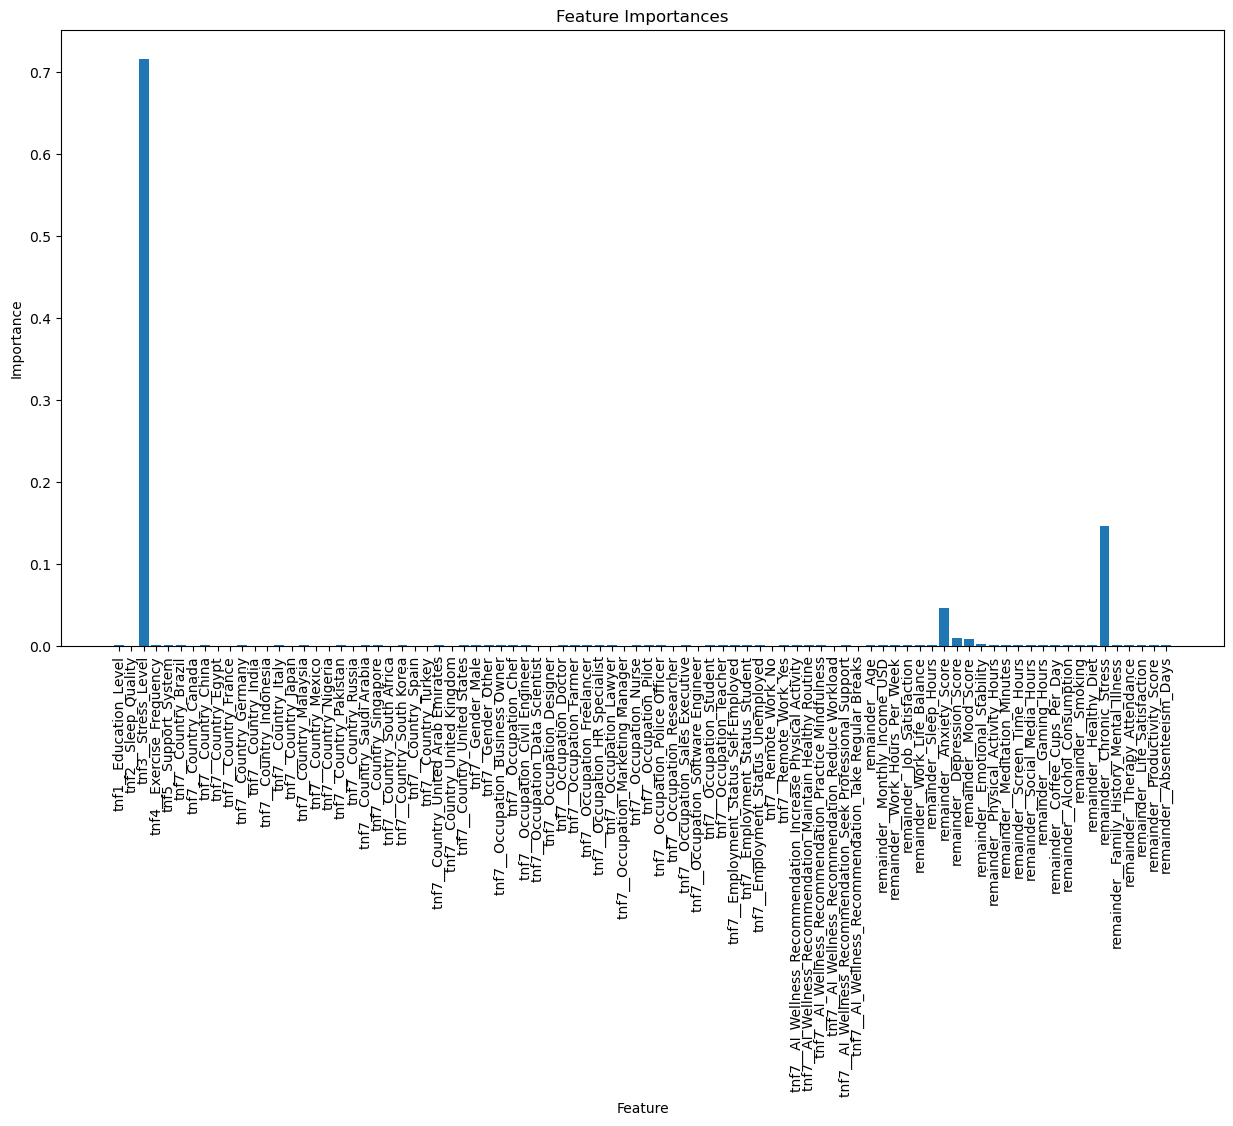

In [378]:
# Graphical Representation
plt.figure(figsize=(15,8))

plt.bar(
    ct.get_feature_names_out(),
    model.feature_importances_
)

plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title("Feature Importances")
plt.xticks(rotation=90)
plt.show()

In [361]:
# Feature Importance
importance = model.feature_importances_
feature_names = ct.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

                         Feature  Importance
2             tnf3__Stress_Level    0.715612
80     remainder__Chronic_Stress    0.146301
67      remainder__Anxiety_Score    0.046988
68   remainder__Depression_Score    0.009971
69         remainder__Mood_Score    0.008347
..                           ...         ...
19          tnf7__Country_Russia    0.000152
17         tnf7__Country_Nigeria    0.000000
11           tnf7__Country_India    0.000000
27  tnf7__Country_United Kingdom    0.000000
45   tnf7__Occupation_Researcher    0.000000

[86 rows x 2 columns]


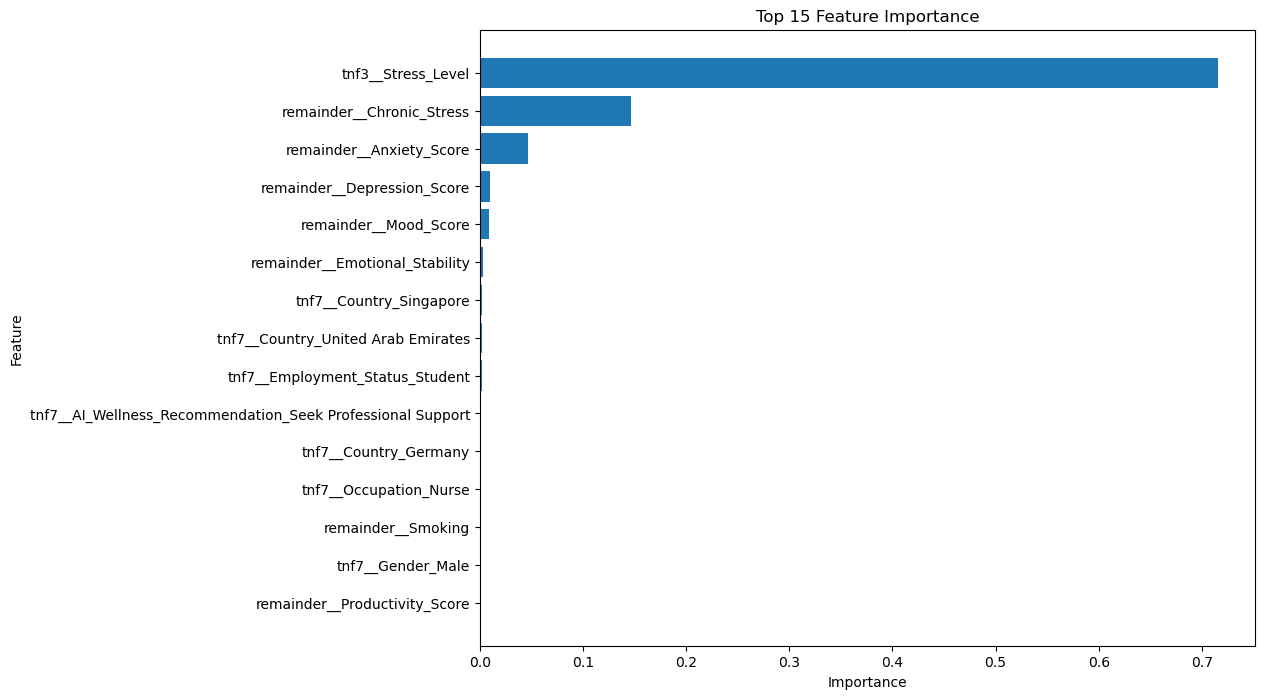

In [322]:
# Graphical Representation
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'].head(15),
    feature_importance['Importance'].head(15)
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance')

plt.gca().invert_yaxis()
plt.show()

In [351]:
print(pd.crosstab(
    df['Mental_Health_Status'],
    df['Stress_Level'],
    normalize='index'
))

Stress_Level              High       Low  Moderate
Mental_Health_Status                              
Critical              0.646132  0.000000  0.353868
Healthy               0.000000  0.805589  0.194411
Needs Attention       0.024262  0.081583  0.894154


In [353]:
print(pd.crosstab(
    df['Mental_Health_Status'],
    df['Chronic_Stress'],
    normalize='index'
))

Chronic_Stress               0         1
Mental_Health_Status                    
Critical              0.385097  0.614903
Healthy               1.000000  0.000000
Needs Attention       0.981555  0.018445


In [382]:
# Conclusion
# so When we take all the features and take the 1 target output it shows 99 accuracy due to the column burn out risk and mental health status
# are reperesnt same due to corelation data after droping the column now the model shows 82.735 Accuracy 